# Seoul Bike Data

**Goal**: Predict the amount of bikes that will be rented based on temporal factors like time, season, weather conditions etc.

In [2]:
# Import necessary Libraries
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df = pd.read_csv('data/SeoulBikeData.csv', encoding='unicode_escape')
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [4]:
df.describe()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [5]:
df.shape

(8760, 14)

## Data Cleaning

In [6]:
df.isnull().sum()

Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64

In [7]:
df.drop(columns='Date', inplace=True)
df.head()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [8]:
df.columns

Index(['Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day'],
      dtype='str')

In [9]:
# Preprocessing: parse Date, extract temporal features, and encode categoricals
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
    df['Day'] = df['Date'].dt.day
    df['Month'] = df['Date'].dt.month
    df['Year'] = df['Date'].dt.year
    df['Weekday'] = df['Date'].dt.weekday
    df.drop(columns='Date', inplace=True)

categoricals = ['Seasons', 'Holiday', 'Functioning Day']
# One-hot encode categorical columns and drop the first level to avoid collinearity
df = pd.get_dummies(df, columns=categoricals, drop_first=True)

df.shape

(8760, 15)

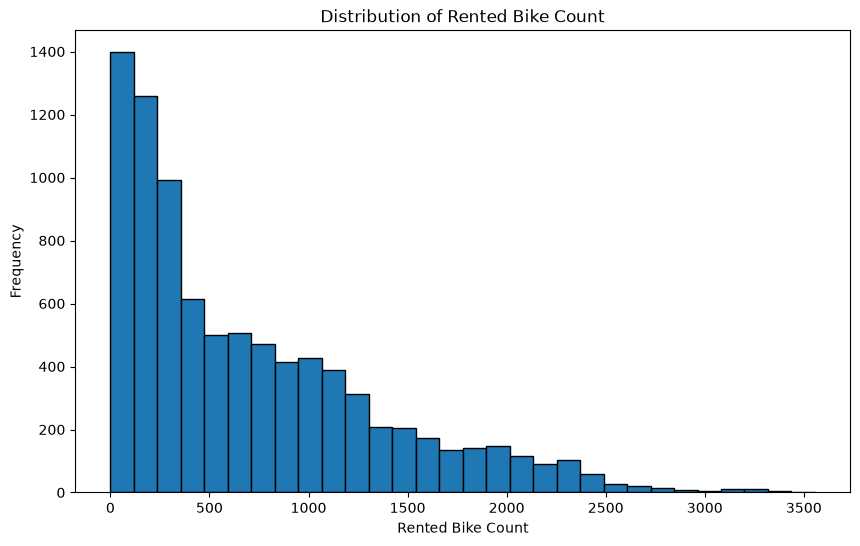

In [10]:
# Plot a distribution of the target variable
plt.figure(figsize=(10, 6))
plt.hist(df['Rented Bike Count'], bins=30, edgecolor='black')
plt.title('Distribution of Rented Bike Count')
plt.xlabel('Rented Bike Count')
plt.ylabel('Frequency')
plt.show()

# Train Model
1. Linear Regression model
2. Random Forest Regressor model
3. XGBoost (XGBRegressor)

In [11]:
# Train-Validation-Test Split

X = df.drop('Rented Bike Count', axis=1)
y = df['Rented Bike Count']

# Save feature columns after encoding so we can align new data later
feature_cols = X.columns.copy()

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")


Training set: 3066 samples
Validation set: 3066 samples
Test set: 2628 samples


### Linear Regression

In [12]:
lrm = LinearRegression()
lrm.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](14,)","[ 28.04, 21.82, -8.84,...,-373.74, 154.94, 933.57]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](14,)","['Hour','Temperature(°C)','Humidity(%)',...,'Seasons_Winter', 'Holiday_No Holiday','Functioning Day_Yes']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-294
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,14
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(14)


In [13]:
val_predictions = lrm.predict(X_val)
test_predictions = lrm.predict(X_test)

print(f"Validation MSE: {np.sqrt(mean_squared_error(y_val, val_predictions)):.2f}")
print(f"Validation R2 Score: {r2_score(y_val, val_predictions):.2f}")

print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, test_predictions)):.2f}")
print(f"Test R2 Score: {r2_score(y_test, test_predictions):.2f}")

Validation MSE: 437.01
Validation R2 Score: 0.56
Test RMSE: 437.11
Test R2 Score: 0.53


Because the RMSE and R2 scores are not satisfactory, we will try a Random Forest Regressor model to see if we can improve the performance.

### Random Forest Regression

In [14]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [15]:
val_predictions = rf.predict(X_val)
test_predictions = rf.predict(X_test)

print(f"Validation RMSE: {np.sqrt(mean_squared_error(y_val, val_predictions)):.2f}")
print(f"Validation R2 Score: {r2_score(y_val, val_predictions):.2f}")

print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, test_predictions)):.2f}")
print(f"Test R2 Score: {r2_score(y_test, test_predictions):.2f}")


Validation RMSE: 243.47
Validation R2 Score: 0.86
Test RMSE: 251.31
Test R2 Score: 0.85


In [16]:
# Check which columns have the highest influence on the target variable
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': importances
})

print(feature_importance_df.sort_values(by='Coefficient', ascending=False))

                      Feature  Coefficient
0                        Hour     0.301009
1             Temperature(°C)     0.296209
2                 Humidity(%)     0.093741
6     Solar Radiation (MJ/m2)     0.081713
13        Functioning Day_Yes     0.078310
5   Dew point temperature(°C)     0.037125
11             Seasons_Winter     0.031708
7                Rainfall(mm)     0.023012
3            Wind speed (m/s)     0.022807
4            Visibility (10m)     0.020190
9              Seasons_Spring     0.008749
12         Holiday_No Holiday     0.002653
10             Seasons_Summer     0.002251
8               Snowfall (cm)     0.000523


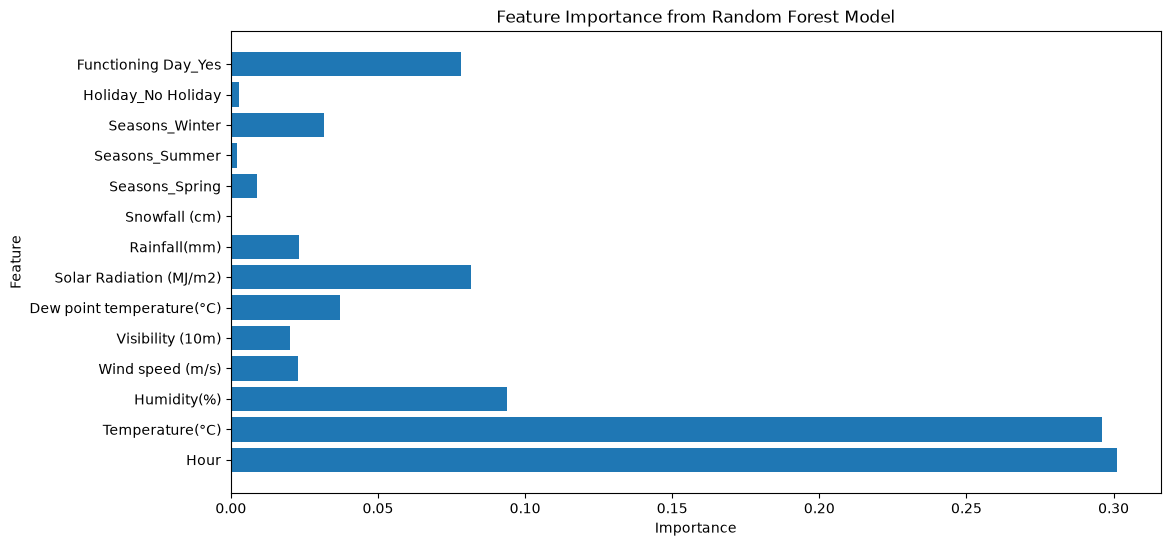

In [27]:
plt.figure(figsize=(12, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Coefficient'])
plt.title('Feature Importance from Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

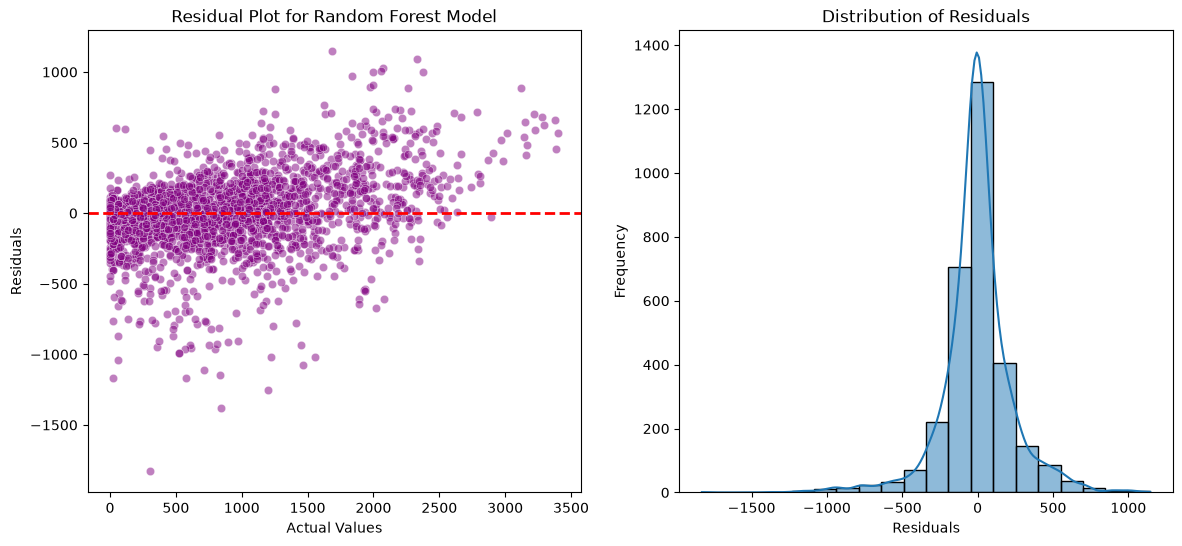

In [26]:
# Residual plot for Random Forest model
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
residuals = y_val - val_predictions
sns.scatterplot(x=y_val, y=residuals, alpha=0.5, color='purple', ax=axs[0])
axs[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axs[0].set_title('Residual Plot for Random Forest Model')
axs[0].set_xlabel('Actual Values')
axs[0].set_ylabel('Residuals')

# Plot 2: Residuals distribution histogram
sns.histplot(residuals, bins=20, kde=True, ax=axs[1])
axs[1].set_title('Distribution of Residuals')
axs[1].set_xlabel('Residuals')
axs[1].set_ylabel('Frequency')
plt.show()

The residual plot shows the residuals being scattered around the horizontal line at zero but after 1500 it is skewed towards the positive side. This indicates that the model is underestimating the bike rentals for higher values, which could be due to the model not capturing some underlying patterns in the data or the presence of outliers. Further investigation and possibly more complex models or feature engineering may be needed to improve predictions for these higher rental counts.

### XGBoost

In [19]:
# Ensure training/validation/test features are numeric. If object columns exist, one-hot encode them across splits.
obj_cols = list(X_train.select_dtypes(include=['object']).columns)
if obj_cols:
    print('Object-type columns detected:', obj_cols)
    # Concatenate to ensure consistent dummy columns across splits
    combined = pd.concat([X_train, X_val, X_test])
    combined = pd.get_dummies(combined, columns=obj_cols, drop_first=True)
    # Re-split
    X_train = combined.loc[X_train.index].copy()
    X_val = combined.loc[X_val.index].copy()
    X_test = combined.loc[X_test.index].copy()
    # Update feature list
    feature_cols = X_train.columns.copy()

# Final sanity check: ensure all dtypes are numeric or category
non_numeric = [c for c, t in X_train.dtypes.items() if t not in ['int64', 'float64', 'bool', 'category']]
if non_numeric:
    raise ValueError(f"Non-numeric columns present in training data: {non_numeric}")

# Train XGBoost
xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5)
xgb.fit(X_train, y_train)


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [20]:
val_predictions = xgb.predict(X_val)
test_predictions = xgb.predict(X_test)

print(f"Validation RMSE: {np.sqrt(mean_squared_error(y_val, val_predictions)):.2f}")
print(f"Validation R2 Score: {r2_score(y_val, val_predictions):.2f}")

print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, test_predictions)):.2f}")
print(f"Test R2 Score: {r2_score(y_test, test_predictions):.2f}")

Validation RMSE: 236.36
Validation R2 Score: 0.87
Test RMSE: 242.30
Test R2 Score: 0.86


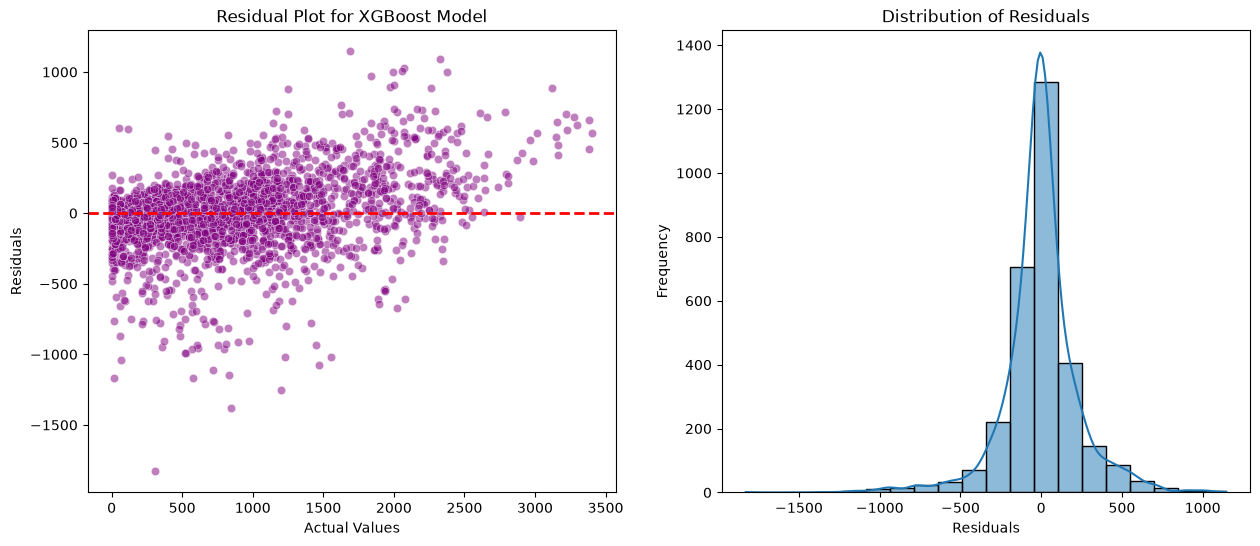

In [ ]:
# Residual plots for XGBoost model
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
residuals = y_val - val_predictions

# Plot 1: Residuals scatter plot
sns.scatterplot(x=y_val, y=residuals, alpha=0.5, color='purple', ax=axs[0])
axs[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axs[0].set_title('Residual Plot for XGBoost Model')
axs[0].set_xlabel('Actual Values')
axs[0].set_ylabel('Residuals')

# Plot 2: Residuals distribution histogram
sns.histplot(residuals, bins=20, kde=True, ax=axs[1])
axs[1].set_title('Distribution of Residuals')
axs[1].set_xlabel('Residuals')
axs[1].set_ylabel('Frequency')
plt.show()

The residual plot shows the residuals being scattered around the horizontal line at zero but after 1500 it is skewed towards the positive side. This indicates that the model is underestimating the bike rentals for higher values, which could be due to the model not capturing some underlying patterns in the data or the presence of outliers. Further investigation and possibly more complex models or feature engineering may be needed to improve predictions for these higher rental counts.

#### Save trained model


In [57]:
with open('model/xgb-model.pkl', 'wb') as file:
    pickle.dump(xgb, file)

with open("model/feature_cols.pkl", "wb") as f:
    pickle.dump(feature_cols, f)

## Predictions
Let's do some test predictions on this data

In [55]:
X_new = pd.DataFrame({
    'Hour': [10],
    'Temperature(°C)': [20],
    'Humidity(%)': [50],
    'Wind speed (m/s)': [3],
    'Visibility (10m)': [2000],
    'Dew point temperature(°C)': [10],
    'Solar Radiation (MJ/m2)': [5],
    'Rainfall(mm)': [0],
    'Snowfall (cm)': [0],
    'Seasons': ['Summer'],
    'Holiday': ['No Holiday'],
    'Functioning Day': ['Yes']
})

In [58]:
# Prepare new sample for prediction: align columns to training features
X_new = pd.get_dummies(X_new)

# Fallback: ensure feature_cols exists by deriving from available training variables
if 'feature_cols' not in globals():
    if 'X_train' in globals():
        feature_cols = X_train.columns.copy()
    elif 'X' in globals():
        feature_cols = X.columns.copy()
    else:
        raise NameError("feature_cols is not defined and training data not available. Run preprocessing and train/test split cells first.")

# Align new data to training features
X_new = X_new.reindex(columns=feature_cols, fill_value=0)

prediction = xgb.predict(X_new)
predictions = np.clip(prediction, 0, None)

print(f"Predicted Rented Bike Count: {predictions[0]:.0f}")

Predicted Rented Bike Count: 1025
